# Визуализация датасета

In [39]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import plotly.graph_objs as go

In [40]:
fifa = pd.read_csv('../datas/fifa-18-demo-player-dataset/CompleteDataset.csv', low_memory=False)

преобразуем некоторые строковые значения столбцов в числовые для лучшей работы. В частности зп игроков и их значения игрового баланса

In [41]:
try:
    fifa['Wage'] = [int(re.findall('\d+',fifa.Wage.values[i])[0])*1000 for i in range(len(fifa))] # заменяем строчные значения зарплат на целочисленные
    fifa['Balance'] = [eval(fifa['Balance'][i]) for i in range(len(fifa))] # преобразуем строковые значения в числовые
except:
    pass

In [42]:
fifa.head(3)

,Unnamed: 0,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,RB,RCB,RCM,RDM,RF,RM,RS,RW,RWB,ST
0,0,Cristiano Ronaldo,32,https://cdn.sofifa.org/48/18/players/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Real Madrid CF,https://cdn.sofifa.org/24/18/teams/243.png,...,61.0,53.0,82.0,62.0,91.0,89.0,92.0,91.0,66.0,92.0
1,1,L. Messi,30,https://cdn.sofifa.org/48/18/players/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,93,93,FC Barcelona,https://cdn.sofifa.org/24/18/teams/241.png,...,57.0,45.0,84.0,59.0,92.0,90.0,88.0,91.0,62.0,88.0
2,2,Neymar,25,https://cdn.sofifa.org/48/18/players/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,94,Paris Saint-Germain,https://cdn.sofifa.org/24/18/teams/73.png,...,59.0,46.0,79.0,59.0,88.0,87.0,84.0,89.0,64.0,84.0


## Задачи:
### 1. Гистограмма возраста игроков;
### 2. Сравнение зависимости зарплаты от возраста игрока;
### 3. Гистограмма распределения одной из статистик по странам;
### 4. Футболисты какой национальности в среднем имеют самый большой рейтинг? Совпадает ли график с графиком средних самых высоких зарплат, в зависимости от национальности?

## Решение должно соответствовать следующим критериям:
#### - Минимум две визуализации с помощью matplotlib
#### - Минимум две визуализации с помощью Plotly
#### - В каждой визуализации должен использоваться как минимум один атрибут, не использованный в других визуализациях
#### - Решением к заданию должен быть архив, в котором лежат IPYNB файлы визуализаций. Помимо самого кода визуализации и изображения, в ноутбуке должно присутствовать текстовое описание визуализации.
#### - В каждой визуализации должен быть указан заголовок и подписаны оси, если они есть
#### - К каждой визуализации должен быть описан вопрос, на который она отвечает, например:
###### а) Гистограмма возраста укажет на доминирующий возраст и особенности распределения
###### б) Гистограмма среднего Performance по странам определит стабильные и надежные страны, а гистограмма максимума — родины особо ярких игроков

## Реализация с помощью matplotlib

### 1. Гистограмма возраста игроков

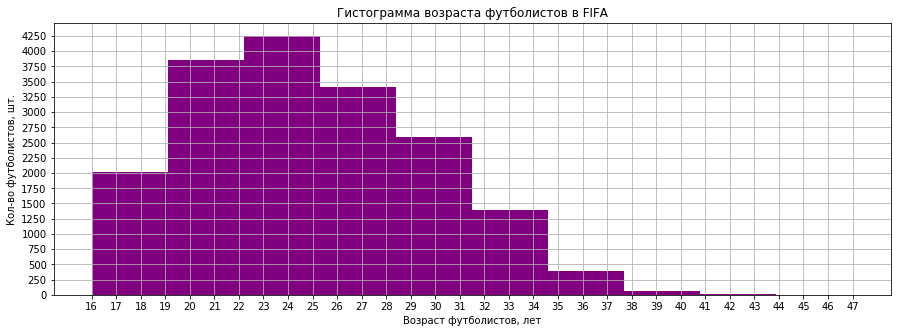

In [43]:
fig,ax = plt.subplots(figsize=(15,5)) # ОО подход, создаем 2 объекта: саму фигуру и оси, которым легче назначать доп. параметры. Тут же указали масштаб для лучшего отображения

ax.grid() # отображение сетки
ax.set_xlabel('Возраст футболистов, лет') # подпись Оx
ax.set_ylabel('Кол-во футболистов, шт.') # подпись Оy
ax.set_title('Гистограмма возраста футболистов в FIFA') # подпись заголовка графика
ax.set_xticks(range(16,48)) # значения, показываемые на Оx
ax.set_yticks(range(0,5000,250)) # значения, показываемые на Оx, с шагом в 250

ax.hist(fifa['Age'], # будем показывать данные столбца возраста нашего дф
        color='purple', # цвет фиолетовый
       );

На гистограмме видно, что больше всего футболистов, возрастом примерно в пределах от 22 до 25 лет.<br>
Очень мало игроков после 38 лет. Не наберется и 250 человек.<br>
Минимальный возраст в FIFA с 16 лет.

### 2. Сравнение зависимости зарплаты от возраста игрока.

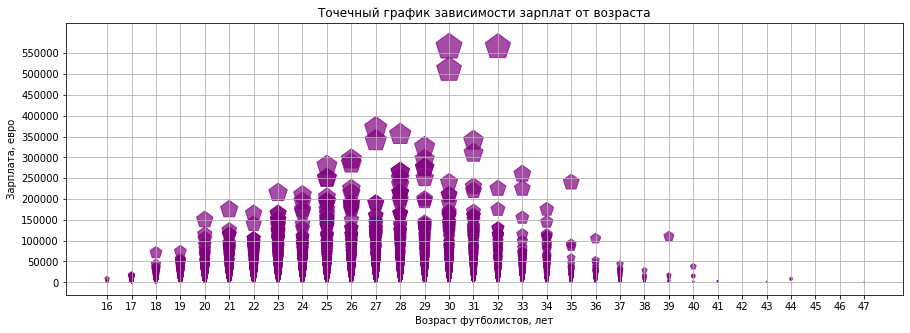

In [44]:
fig,ax = plt.subplots(figsize=(15,5))

ax.grid() # отображение сетки
ax.set_xlabel('Возраст футболистов, лет') # подпись Оx
ax.set_ylabel('Зарплата, евро') # подпись Оy
ax.set_title('Точечный график зависимости зарплат от возраста') # подпись заголовка графика
ax.set_xticks(range(16,48)) # значения, показываемые на Оx
ax.set_yticks(range(0,600000,50000)) # значения, показываемые на Оx, с шагом в 50K

ax.scatter(fifa['Age'].values,
           fifa['Wage'].values,
           color='purple', # цвет точек
           s=fifa['Wage'].values/25/fifa['Age'].values, # размер точек
           alpha=0.7, # прозрачность
           marker='p' # форма точек
          );

Никакой зависимости на глаз определить невозможно.<br>
Возьмем несколько самых дорогих и самых многочисленных клубов. Изобразим их точечные графики и лин. аппроксимации

In [45]:
def Wage_Age_byclub(graph_num, club, color): # функция, рисующая точечный график команды и лин. апроксимацию значений
        if isinstance(graph_num, (list, tuple)): # если несколько строк графиков
            coordinates = ax[graph_num[0]][graph_num[1]]
        elif isinstance(graph_num, (int)): # если графики на одной строке
            coordinates = ax[graph_num]
        team = fifa[fifa['Club'] == club]
        # рисуем точечный график
        coordinates.plot(team['Age'].values, # значения по Ох
                         team['Wage'].values, # значения по Оу
                         color = color, # цвет передан как параметр функции
                         marker='o', # отмечаем значения на графике точками
                         linestyle='', # график точечный, без линий
                         label=club, # подпись к графику
                        );
        coordinates.set_title(club,fontsize='20') # задаем размер текста заголовка графика
        coordinates.tick_params(labelsize = 15) # задаем размер текста отметок на осях
        # рисуем аппроксимацию
        x = team['Age'].values # значения Ох
        y = team['Wage'].values # значения на Оу
        p = np.polyfit(x,y, 1) # полином в указанной степени
        y1 = np.polyval(p, x) # подставляем значения x к полученному полиному
        coordinates.plot(x,y1,color=color,alpha=0.6)

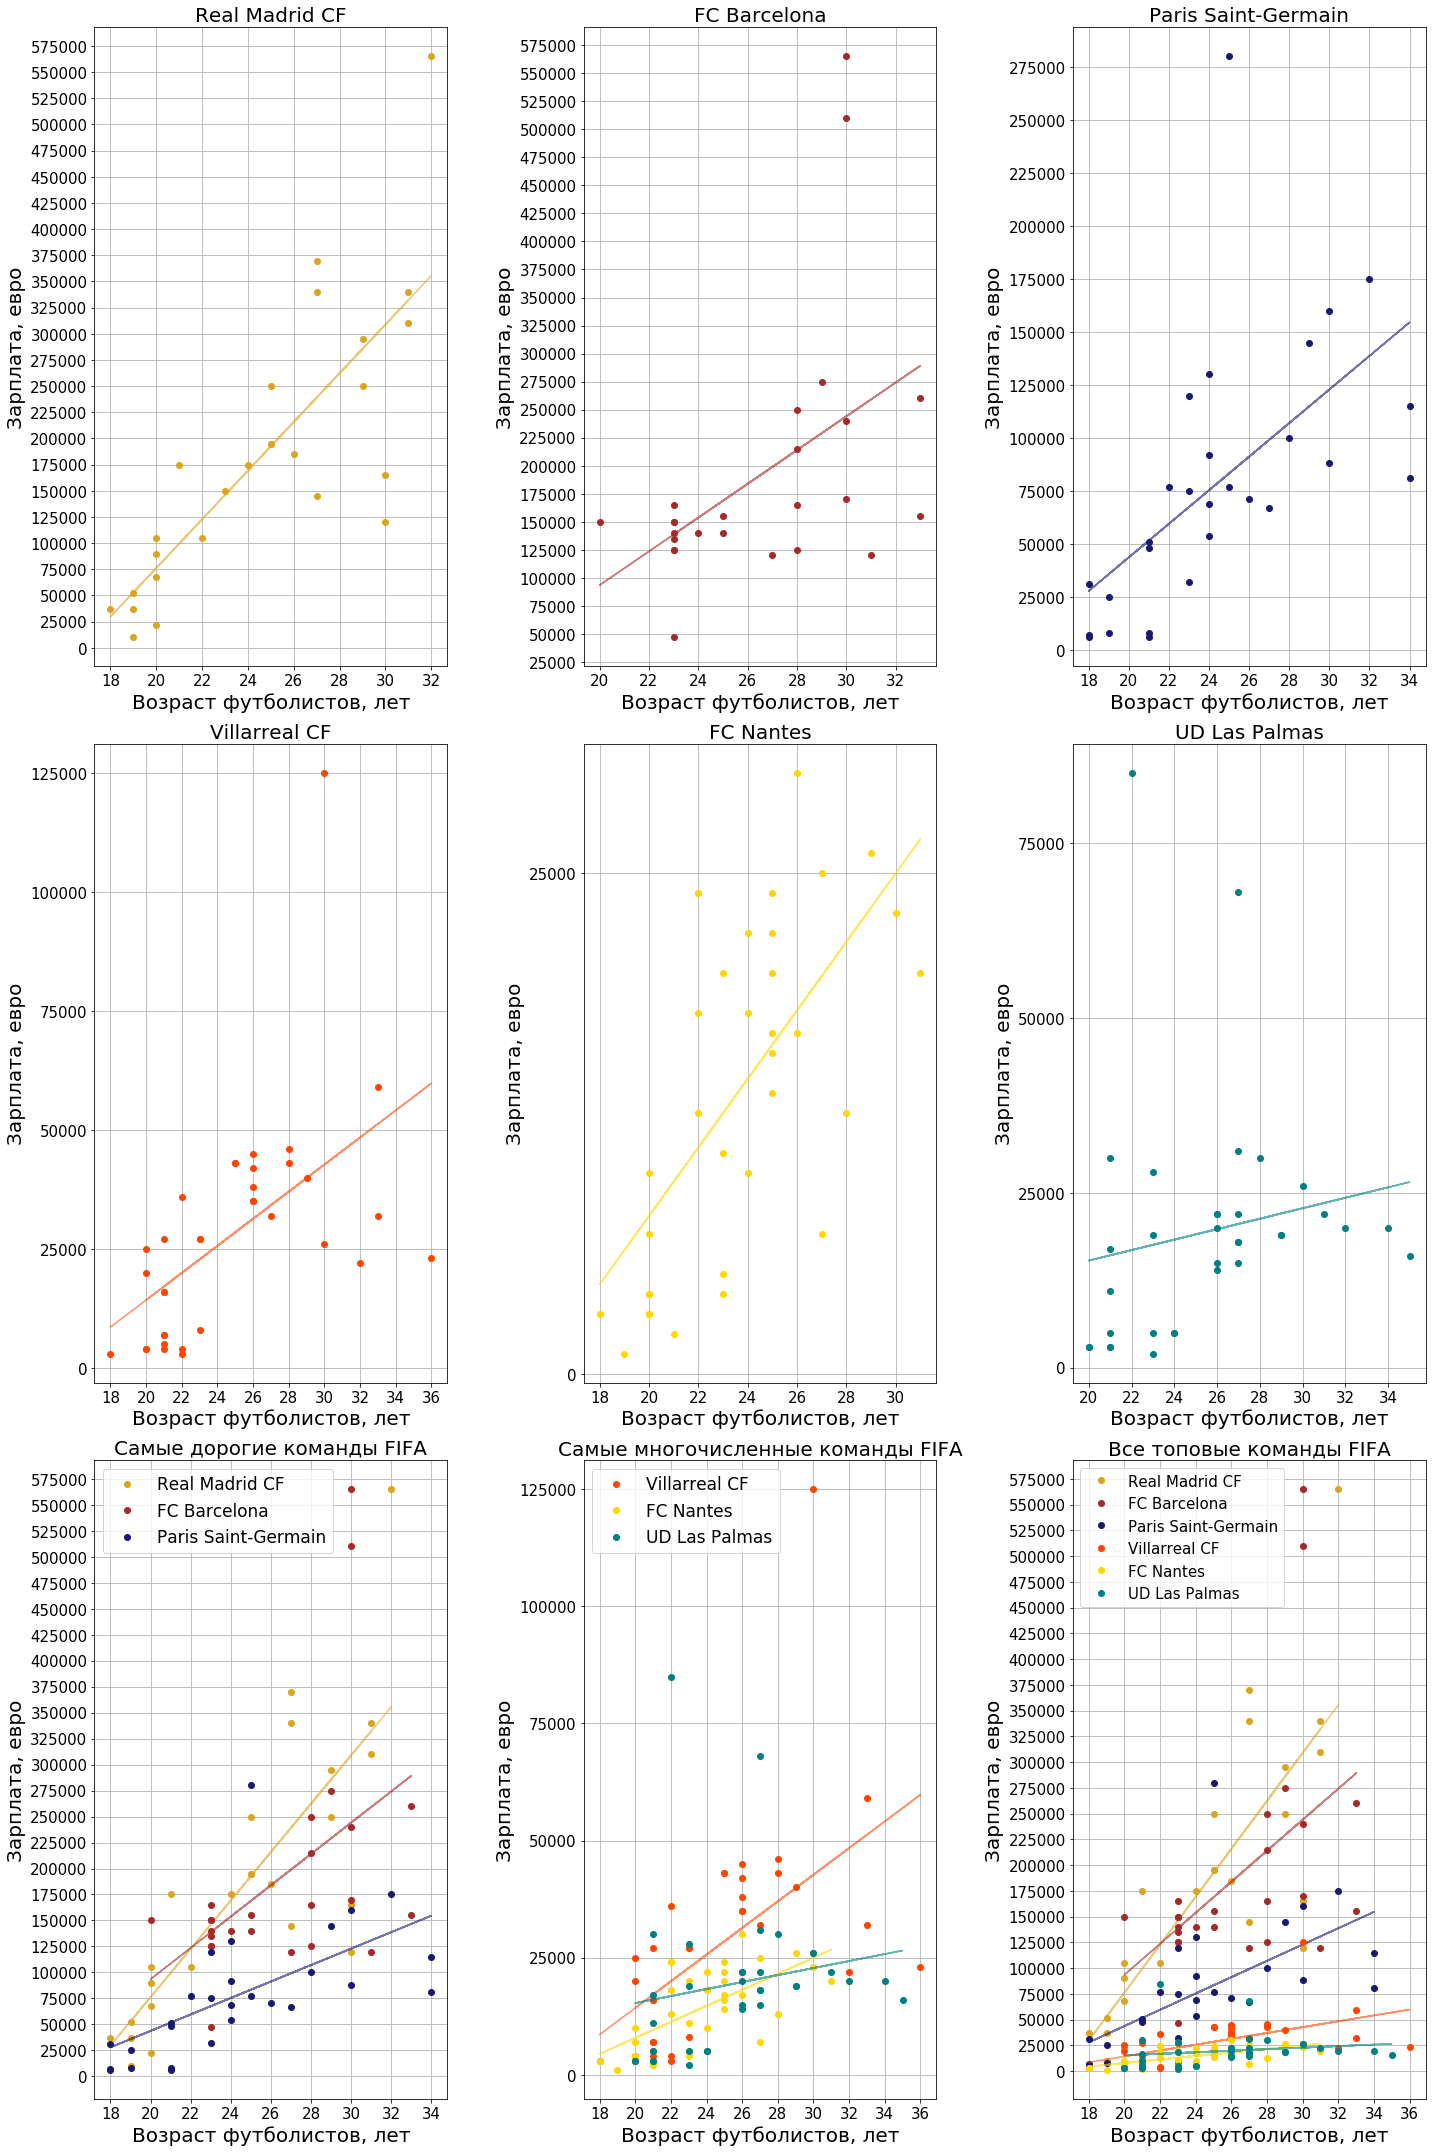

In [46]:
fig,ax = plt.subplots(nrows=3,ncols=3,figsize=(20,30))
# plt.subplots_adjust(wspace=0.3, hspace=0.5) # расстояние между графиками
for row_ax in ax:
    for ax_one in row_ax:
        ax_one.grid()
        ax_one.set_xlabel('Возраст футболистов, лет', fontsize=20) # подпись Оx
        ax_one.set_ylabel('Зарплата, евро', fontsize=20) # подпись Оy
        ax_one.set_xticks(range(16,48,2)) # значения, показываемые на Оx
        ax_one.set_yticks(range(0,600000,25000)) # значения, показываемые на Оx, с шагом в 50K
        
        
Wage_Age_byclub([0,0],'Real Madrid CF','goldenrod')
Wage_Age_byclub([0,1],'FC Barcelona','brown')
Wage_Age_byclub([0,2],'Paris Saint-Germain','midnightblue')

Wage_Age_byclub([1,0],'Villarreal CF','orangered')
Wage_Age_byclub([1,1],'FC Nantes','gold')
Wage_Age_byclub([1,2],'UD Las Palmas','teal')

Wage_Age_byclub([2,0],'Real Madrid CF','goldenrod')
Wage_Age_byclub([2,0],'FC Barcelona','brown')
Wage_Age_byclub([2,0],'Paris Saint-Germain','midnightblue')
ax[2][0].legend(loc='best',fontsize=17)
ax[2][0].set_title('Самые дорогие команды FIFA', fontsize=20)

Wage_Age_byclub([2,1],'Villarreal CF','orangered')
Wage_Age_byclub([2,1],'FC Nantes','gold')
Wage_Age_byclub([2,1],'UD Las Palmas','teal')
ax[2][1].legend(loc='best',fontsize=17)
ax[2][1].set_title('Самые многочисленные команды FIFA', fontsize=20)

Wage_Age_byclub([2,2],'Real Madrid CF','goldenrod')
Wage_Age_byclub([2,2],'FC Barcelona','brown')
Wage_Age_byclub([2,2],'Paris Saint-Germain','midnightblue')
Wage_Age_byclub([2,2],'Villarreal CF','orangered')
Wage_Age_byclub([2,2],'FC Nantes','gold')
Wage_Age_byclub([2,2],'UD Las Palmas','teal')
ax[2][2].legend(loc='best',fontsize=15)
ax[2][2].set_title('Все топовые команды FIFA', fontsize=20)

fig.tight_layout() # автонастройка масштаба

В клубах с возрастом, в среднем, зп увеличивается, что видно по лин. апроксимации<br>
В каждой команде есть 1-2 футболиста, у которых зп значительно выше, чем у сокамандников. Данная величина не зависит от возраста

## Реализация с помощью plotly

### 3. Гистограмма распределения одной из статистик по странам;

Нарисуем график распределения любой величины, данные которой находятся в датасете, например, баланс. Посмотрим как сбалансированы игроки в игре

In [47]:
trace = go.Histogram(x=fifa['Balance'], # величина, распределение которой нужно показать
                     marker_color='darkgreen', # цвет графика
                     histnorm='percent' # теперь величина будет выражена в %
                    )

layout = {'title': {'text': 'Гистограма распределения баланса среди игроков FIFA', # Заголовок графика
                    'x':0.5, # позиционирование title по центру
                   },
          'xaxis_title': 'Значения баланса, %', # подпись Ох 
          'yaxis_title': 'Доля в FIFA, %', # подпись Оу
          'bargap':0.05, # зазор между столбцами гистограмы
    }

go.Figure(data=trace,layout=layout).show()

На графике видно, что в игре баланс игроков подчиняется закону нормального распределения. Есть игроки, у которых значение баланса минимальное, есть игроки у которых все навыки в игре отлично сбалансированы, но в среднем преобладают игроки, у которых наблюдается легкий дисбаланс: одни хороши в нападении, другие в защите (ну или что-то подобное)

### 4. Футболисты какой национальности в среднем имеют самый большой рейтинг?<br>Совпадает ли график с графиком средних самых высоких зарплат, в зависимости от национальности?


In [138]:
x_nat = sorted(fifa['Nationality'].unique()) # значения по Ох: все страны
y_nat = fifa.groupby('Nationality')['Overall'].mean() # значения средние по Оу: общий рейтинг
mark_nat = fifa.groupby('Nationality')['Nationality'].count()/50+7 # переменная, отвечающая за размер точки
y_wag = fifa.groupby('Nationality')['Wage'].mean() # значения средние по Оу2: зарплата


trace_national=go.Scatter(x = x_nat, # ед измерения на Ох
                          y = y_nat, # ед измерения на Оу
                          name='Рейтинг', # подпись графика
                          mode='markers', # форма графика: точечный
                          marker={'size' : mark_nat,  # размер точек графика
                                 'color' : np.arange(len(x_nat)), # цвет точек графика
                                 }
                         )
trace_wage=go.Scatter(x = x_nat, # ед измерения на Ох
                      y = y_wag, # ед измерения на Оу2
                      name='Зарплата', # подпись графика
                      yaxis='y2', # обозначение оси графика
                      opacity = 0.45, # прозрачность
                      mode='lines', # форма графика: линия
                      line={'width' : 1, # толщина линии
                            'color': 'black', # цвет линии
                           }
                     )
layout = {'title': {'text': 'Средние рейтинги и зарплаты игроков разных стран в FIFA', # Заголовок графика
                    'x':0.5, # позиционирование title по центру
                   },
          'xaxis_title': 'Страны, представленные в FIFA', # подпись Ох 
          'yaxis': {'title': 'Рейтинг игроков', # подпись Оу
                   },
          'yaxis2': {'title': 'ЗП игроков, евро', # подпись Оу2
                     'overlaying' : 'y', # показывать поверх имеющейся Оу
                     'side' : 'right', # показывать справа
                    },
    }
data=[trace_national,trace_wage]
go.Figure(data=data,layout=layout).show()

Точечный график показывает средний рейтинг, а линейный - среднюю зарплату игроков, сгруппированных по их гражданству.<br>
<ul>Описание точечного графика:
    <li>Чем выше расположена точка, тем выше средний рейтинг.</li>
    <li>Размер точки зависит от кол-ва игроков в выборке, имеющих  одинаковое гражданство.</li>
</ul>
Забавно получается, судя по графику, в среднем, у белорусов рейтинг выше, чем у игроков из Испании, Англии, Германии. Это обусловленно малым кол-во игроков из Беларусии и большим разбросом значений среди игроков "топовых стран" (в FIFA собраны данные из разных дивизионов, в том числе из тех, где невосокий рейтинг у футболистов)<br>
Так же заметна некоторая не совсем линейная зависимость между средним рейтингом и ср. зарплатой игроков